In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('bmh')
plt.rcParams['axes.facecolor'] = 'white'

In [2]:
y_true = np.load('../test-set-y_true.npy', allow_pickle=True)
y_pred_low = np.load('../test-set-y_pred_low.npy', allow_pickle=True)
y_pred_high = np.load('../test-set-y_pred_high.npy', allow_pickle=True)

In [3]:
mmsis = np.load('../all-mmsis-test.npy', allow_pickle=True)
days = np.load('../all-days-test.npy', allow_pickle=True)
timestamps_dict = np.load('../timestamps-dict.npy', allow_pickle=True)

In [22]:
mistake_mask = (
    (y_true[:, 0, 0] < y_pred_low[:, 0, 0]) |
    (y_true[:, 0, 0] > y_pred_high[:, 0, 0])
)

In [25]:
np.mean( (y_true[:, 0, 1] > y_pred_low[:, 0, 1]) & (y_true[:, 0, 1] < y_pred_high[:, 0, 1]) )

np.float64(0.9386102930299485)

In [23]:
1- np.mean(mistake_mask)

np.float64(0.9179677519129651)

In [4]:
mistake_mask = (
    (y_true[:, 0, 0] < y_pred_low[:, 0, 0]) |
    (y_true[:, 0, 0] > y_pred_high[:, 0, 0])
)

In [5]:
mistake_dict = {}
for ix, (mmsi, day) in enumerate( zip( mmsis, days ) ):

    if (mmsi, day) not in mistake_dict:
        mistake_dict[ (mmsi,day) ] = [ mistake_mask[ix] ]
    else:
        mistake_dict[ (mmsi,day) ].append( mistake_mask[ix] )

In [6]:
error_indices = {}

for (m,d), mask in mistake_dict.items():

    n = len(mask)
    indices = np.array( range(n) )
    error_ix = indices[mask]

    if len(error_ix) > 0:
        error_indices[m,d] = error_ix

In [7]:
import pandas as pd

In [8]:
df = pd.read_csv('../data/df-prepared.csv')
grouped = df.groupby(by=['MMSI', 'day'])
error_data = {}

for (mmsi, day), data in grouped:
    if (mmsi, day) in error_indices:
        indices = error_indices[(mmsi, day)]
        error_data[(mmsi, day)] = data.iloc[indices, :]

In [10]:
def box_plot_anomalies(error_data, df, col):
    values = []
    for (mmsi, day), data in error_data.items():
        values.extend( list(data[col].values) )

    fig, (ax1,ax2) = plt.subplots(ncols=2)
    ax1.boxplot(values)
    ax1.set_ylim((df[col].min(), df[col].max()))
    ax1.set_title(f'{col}-klaidos')

    ax2.boxplot(df[col])
    ax2.set_ylim((df[col].min(), df[col].max()))
    ax2.set_title(f'{col}-normalus')

    plt.tight_layout()
    plt.savefig(f'comparison-{col}.png', dpi=750)
    plt.show()

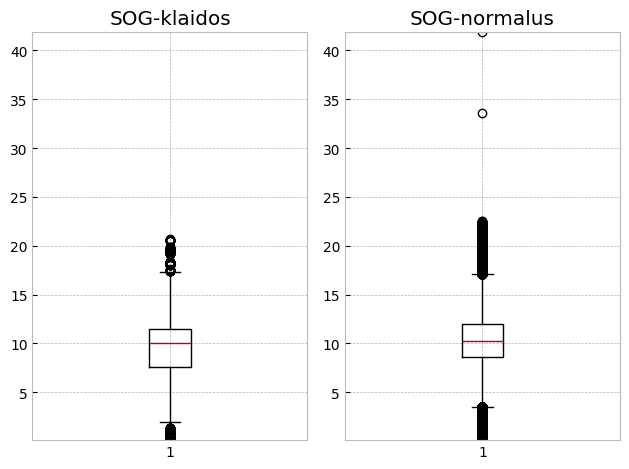

In [11]:
box_plot_anomalies(error_data, df, 'SOG')

In [ ]:
box_plot_anomalies(error_data, df, 'COG')

In [ ]:
box_plot_anomalies(error_data, df, 'Width')

In [ ]:
box_plot_anomalies(error_data, df, 'Length')

In [ ]:
df

In [ ]:
df.columns

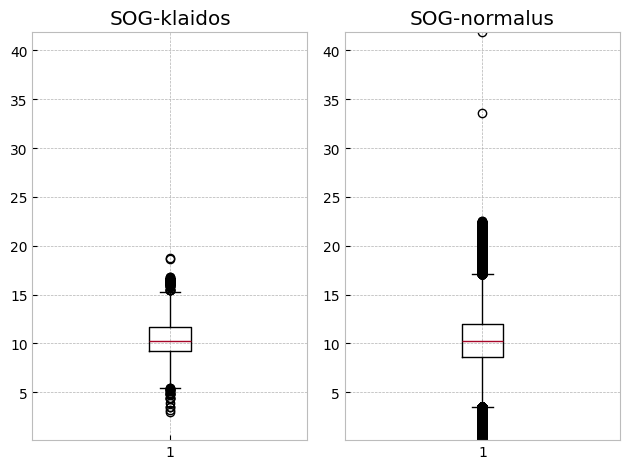

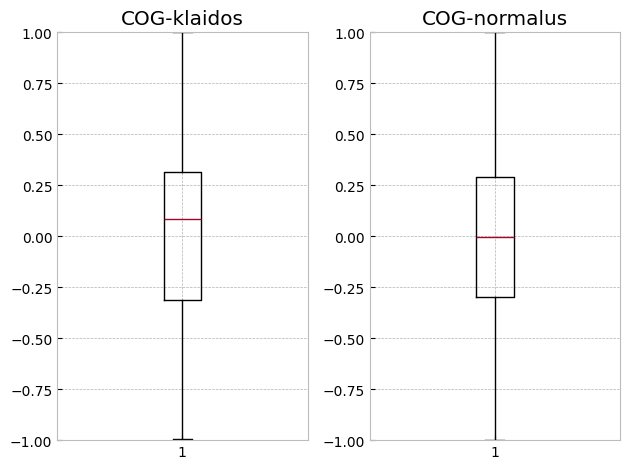

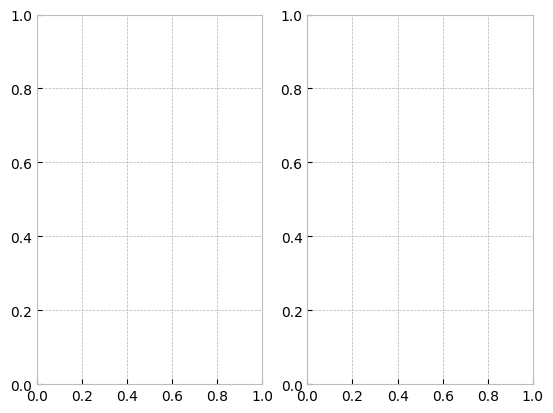

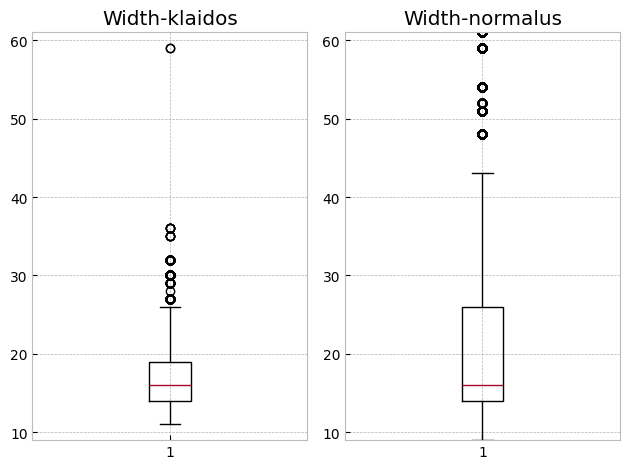

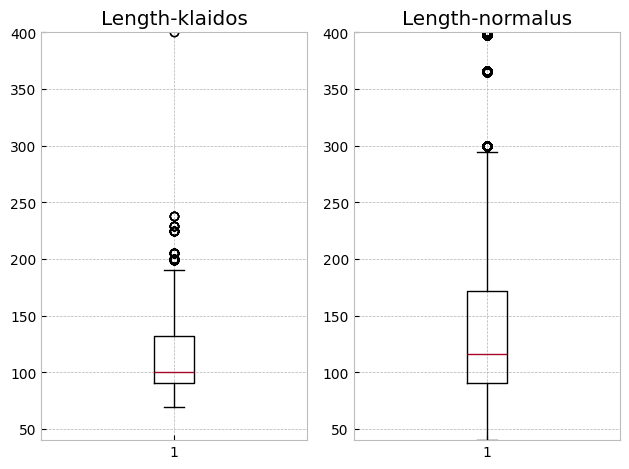

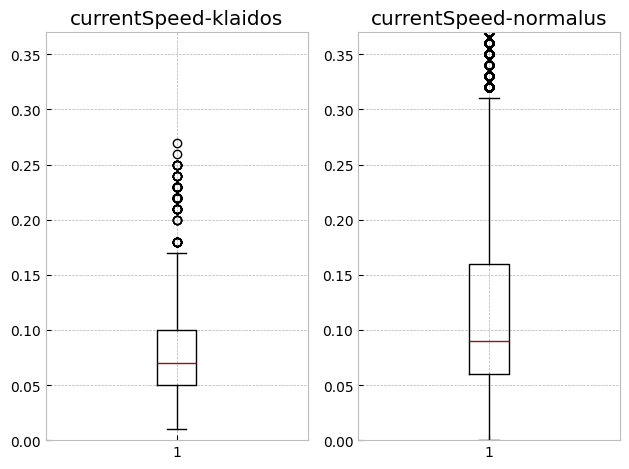

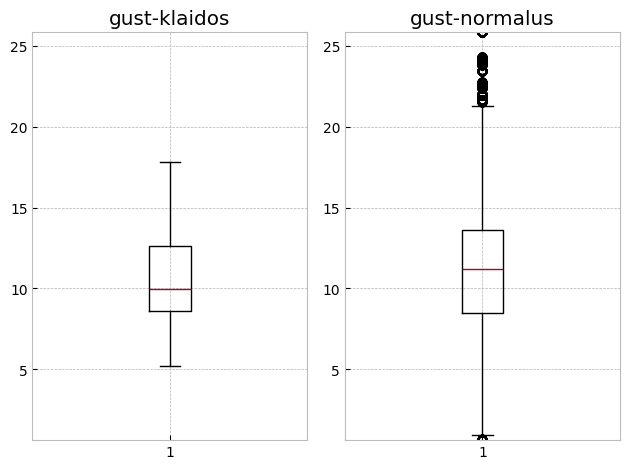

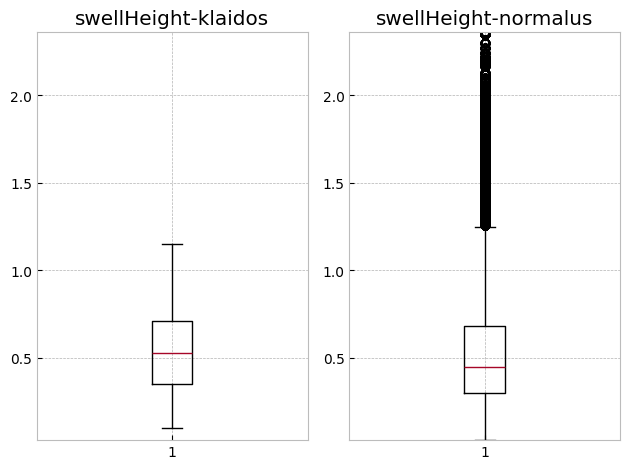

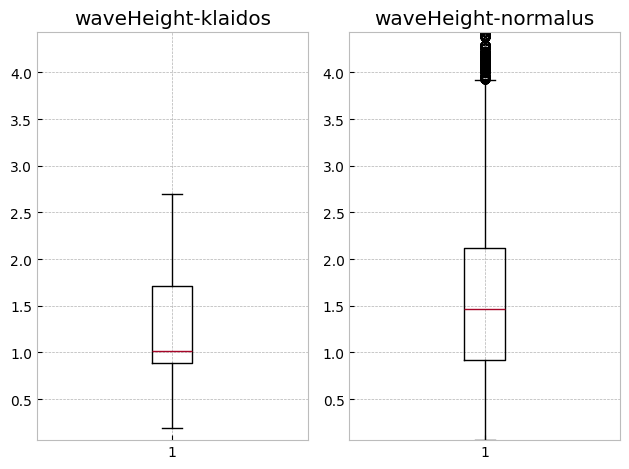

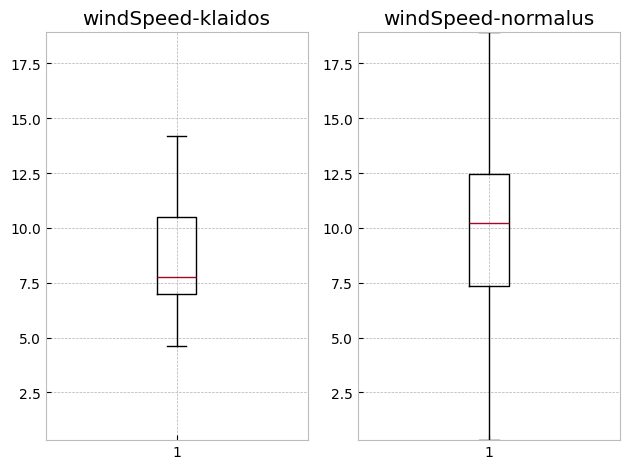

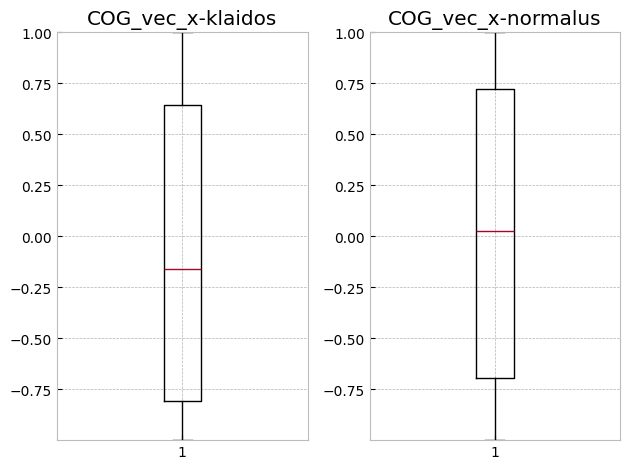

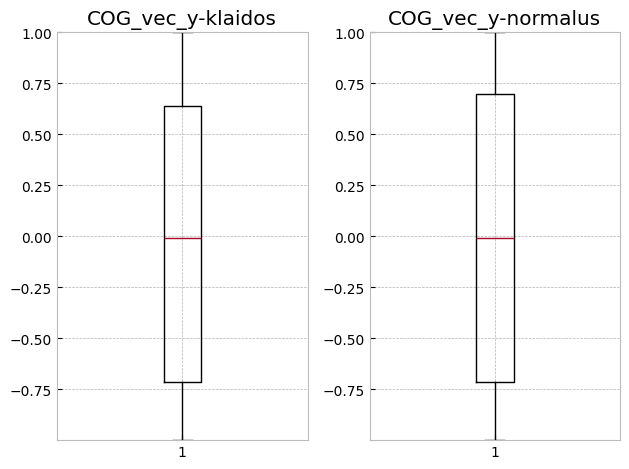

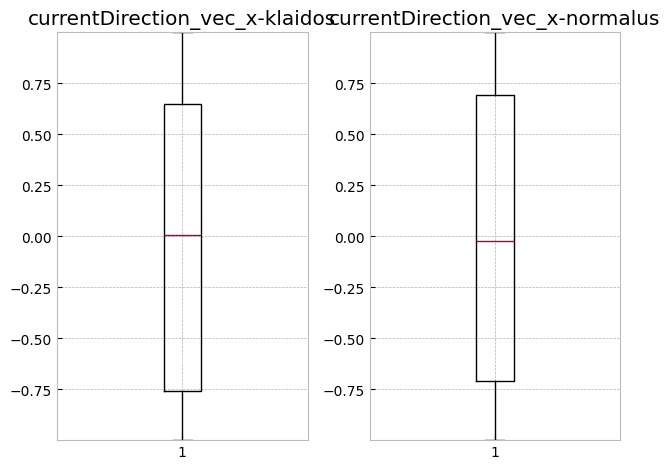

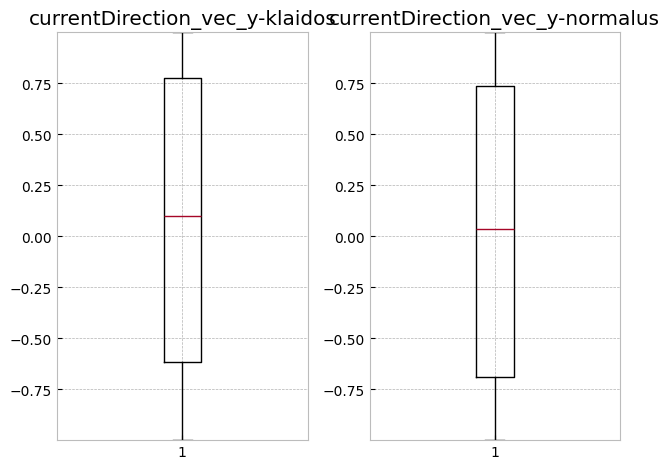

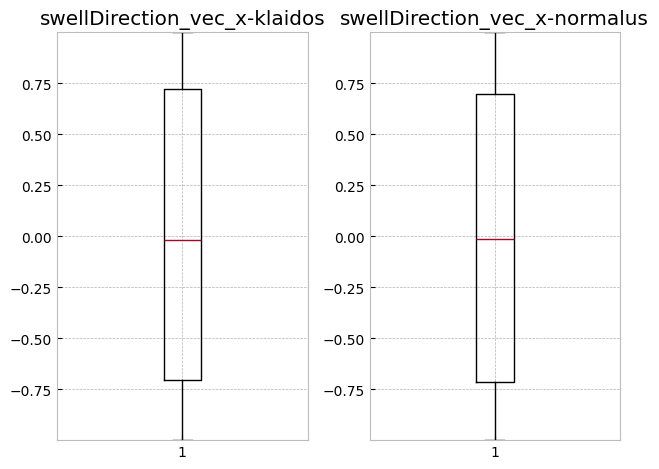

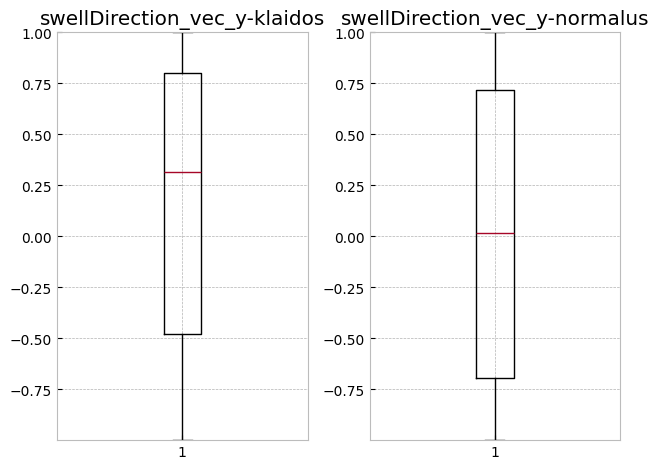

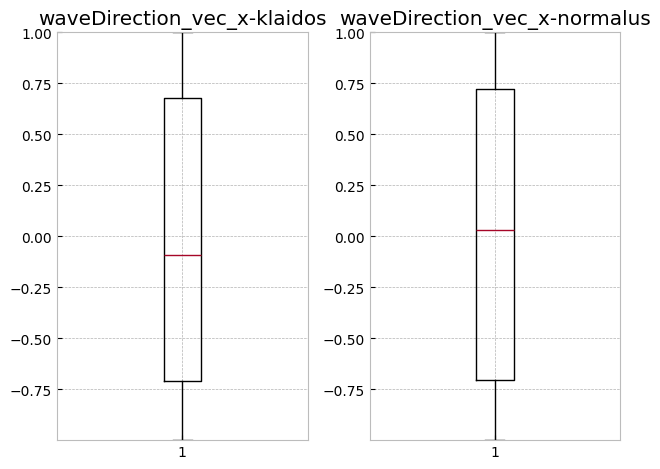

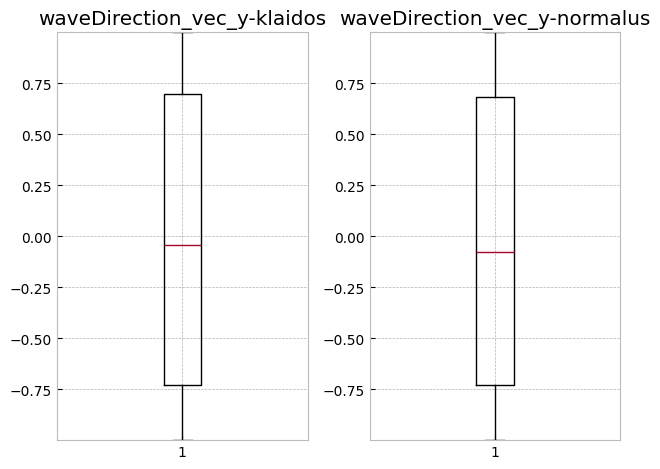

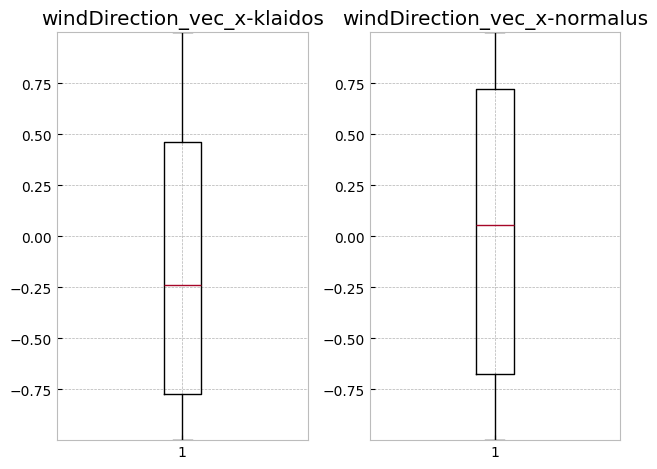

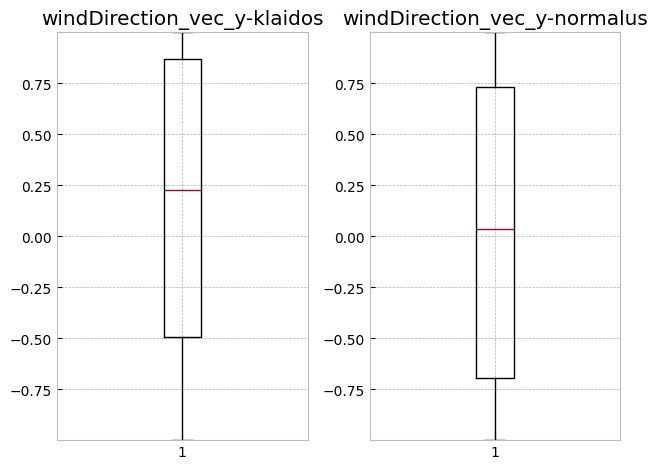

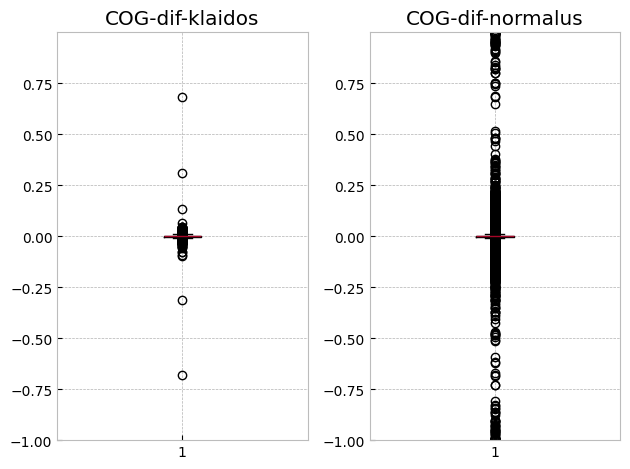

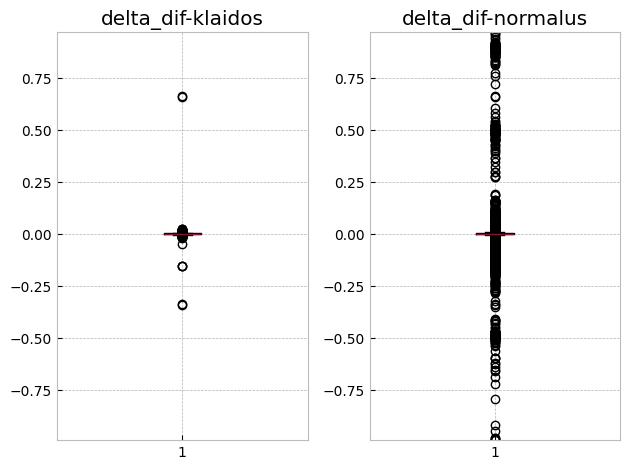

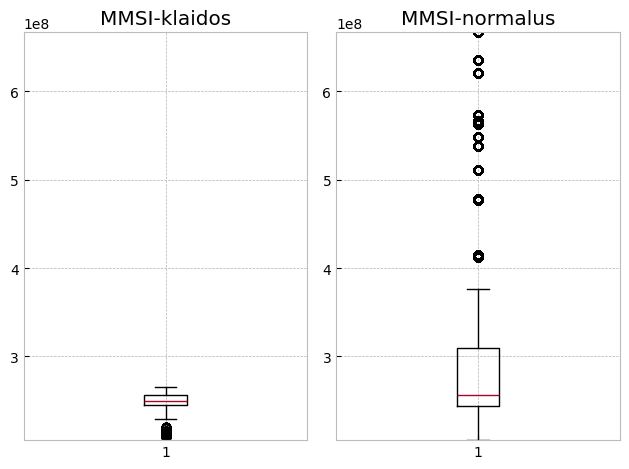

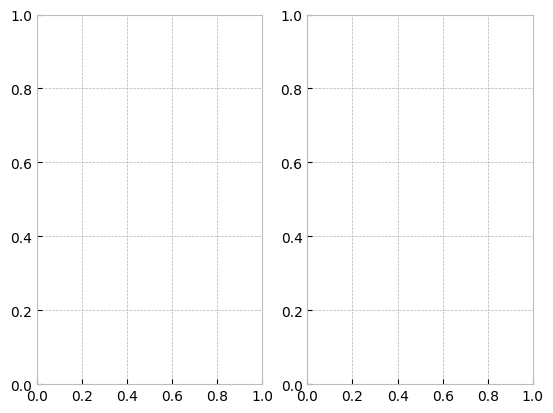

In [20]:
for col in df.columns:
    try:
        box_plot_anomalies(error_data, df, col)
    except:
        continue

In [18]:
mmsis

array([205168000, 205168000, 205168000, ..., 667002347, 667002347,
       667002347], shape=(53530,))

In [19]:
days

array(['2026-01-31', '2026-01-31', '2026-01-31', ..., '2026-01-31',
       '2026-01-31', '2026-01-31'], shape=(53530,), dtype='<U10')

In [20]:
mistake_mask

array([False, False, False, ...,  True, False, False], shape=(74361,))

In [12]:
mistake_counts = {}
mmsi_mistake_table = np.unique( mmsis[mistake_mask], return_counts=True )
days = np.unique( days[mistake_mask], return_counts=True )

for mmsi, mistake_count in zip(*mmsi_mistake_table):
    mistake_counts[mmsi] = mistake_count

IndexError: boolean index did not match indexed array along axis 0; size of axis is 53530 but size of corresponding boolean axis is 74361

In [13]:
mmsi_dict = {
    mmsi: mistakes
    for mmsi, mistakes in zip( *np.unique(mmsis, return_counts=True) )
}

In [14]:
import pandas as pd

In [15]:
mistake_df = {'mmsi': [], 'mistake_count': [], 'mistake_freq': [], 'total_seqs': []}

for mmsi, mistakes in mistake_counts.items():
    mistake_df['mmsi'].append(mmsi)
    mistake_df['mistake_count'].append(mistakes)
    mistake_df['total_seqs'].append(mmsi_dict[mmsi])
    mistake_df['mistake_freq'].append(mistakes / mmsi_dict[mmsi])

mistake_df = pd.DataFrame(mistake_df)

In [16]:
more_than_yipeng3 = mistake_df[ 1 - mistake_df['mistake_freq'] < 0.9 ]
more_than_yipeng3

,mmsi,mistake_count,mistake_freq,total_seqs


In [ ]:
df = pd.read_csv('../data/df-prepared.csv')

In [ ]:
mmsi_mask = df['MMSI'].apply( lambda x: x in more_than_yipeng3['mmsi'].unique() )

In [ ]:
df[mmsi_mask]['Cargo type'].unique()

In [ ]:
df[mmsi_mask]['Length'].unique()

In [ ]:
df[mmsi_mask]['Width'].unique()

## Laivų specifika (remiantis MarineTraffic ir VesselFinder)

219136000 - 200 x 36 m krovininis A pavojingumo klasės laivas, gabenantis labai pavojingą krovinį.

235102851 - 177 / 28 m krovininis laivas, gabenantis nepavojingą krovinį

244130689 - 196 / 26 m krovininis Ro-Ro A pavojingumo klasės laivas, gabenantis pavojingą krovinį.

244130873 - 137 / 22 m krovininis laivas, gabenantis nepavojingą krovinį

246191000 - 137 / 22 m krovininis A pavojingumo klasės laivas, gabenantis labai pavojingą krovinį.

255806507 - 300 / 48 m krovininis D pavojingumo klasės laivas.

257516000 - 213 / 32 m krovininis laivas

314837000 - 134 / 19 m krovininis laivas

341578001 - 89 / 13 m krovininis laivas

352586000 - 229 / 32 m

354711000 - 196 / 33 m

636016848 - 199 / 32 m

636017277 - 200 / 32 m

### Klaidų analizės planas:

1. Laivų specifikos (ilgis, plotis) prieš
2. Greičio ir pozicijos reikšmės
3. Požyimių grafikai
4. 